In [9]:
using DelaunayTriangulation
using GMT

In [5]:
points = rand(2, 50)

2×50 Matrix{Float64}:
 0.985233  0.472185   0.339194  0.928615  …  0.220921  0.677543  0.691661
 0.397584  0.0874786  0.343657  0.210641     0.418521  0.22052   0.644529

In [68]:
triangulation = DelaunayTriangulation.triangulate(points)
tessellation = DelaunayTriangulation.voronoi(triangulation)
conv_hull_indx = DelaunayTriangulation.get_convex_hull_vertices(triangulation)

12-element Vector{Int64}:
 36
 35
 16
 21
  6
 39
 26
  1
 47
 38
 27
 36

In [ ]:
poly_indices=DelaunayTriangulation.get_polygons(tessellation)

x=[]
y=[]

unbounded = Set(DelaunayTriangulation.get_unbounded_polygons(tessellation))

for i in 1:num_polygons(tessellation) 

    if(i ∉ unbounded)

    vertices_indices = get_polygon(tessellation, i)
    
    for indx in vertices_indices

        my_point = get_polygon_point(tessellation, indx)

        for indx in vertices_indices
    
            push!(x,my_point[1])
            push!(y,my_point[2])
    
        end
    end 
    
        push!(x,NaN)
        push!(y,NaN)


    end


end

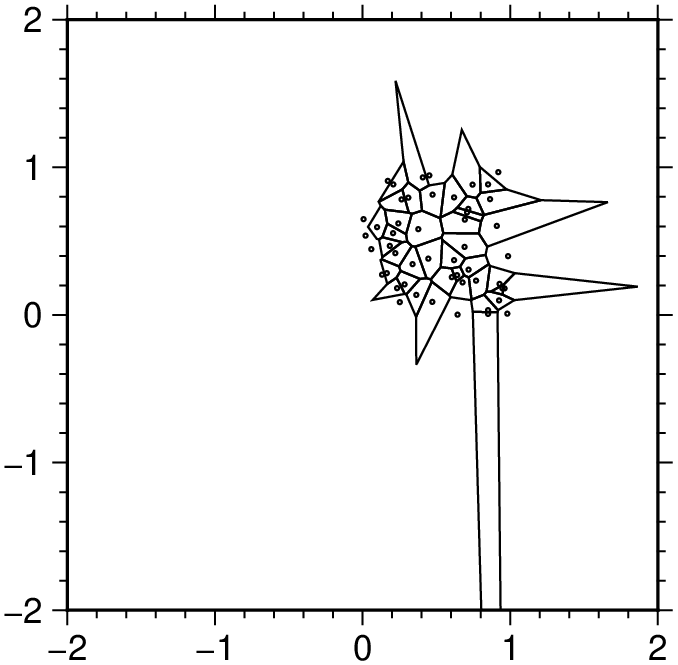

In [65]:
GMT.plot(x,y,region=[-2,2,-2,2],J="X5c")
GMT.scatter!(x=points[1,:],y=points[2,:],S="c1p",show=true)

In [54]:
vertices = get_polygon(tessellation, 2)
pⱼ₊₁ = get_polygon_point(tessellation, vertices[1])

(0.5964393755470189, 0.12069647489504379)

In [30]:
poly_indices[1]

10-element Vector{Int64}:
 77
 -8
 -5
 23
 64
 63
 12
 70
  9
 77

In [ ]:
unbounded = Set(DelaunayTriangulation.get_unbounded_polygons(tessellation))
polygons =  DelaunayTriangulation.get_area(tessellation, i)

Set{Int64} with 11 elements:
  39
  35
  16
  1
  47
  6
  21
  36
  38
  27
  26

In [ ]:
function voronoi_areas(x::AbstractVector{Float64}, y::AbstractVector{Float64})
    points = [x'; y']
    triangulation = triangulate(points)
    tessellation = voronoi(triangulation)
    areas = fill(-1.0, length(x))

    unbounded = Set(DelaunayTriangulation.get_unbounded_polygons(tessellation))
    for i in eachindex(areas)
        if i in unbounded
            continue
        end
        areas[i] = DelaunayTriangulation.get_area(tessellation, i)
    end

    return areas
end